Physics-informed neural networks (PINNs)
================================

In [194]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import optuna
import pandas as pd
from src.logging.logging import TrialLoggingCallback
from pinn_alfa import Ponte
from lightning.pytorch.loggers import CSVLogger
import torch
from src.ferramentas.DataModule import DataModule
from src.ferramentas.Module import Module
import lightning as L

## Introdução

De forma geral os seres humanos estudiosos das ciências naturais sempre se deparam com um problema: a complexidade dos problemas que abordam. O trabalho é cria rum modelo e testá-lo. Mas e quando este tem muitas variáveis, dimensões e implicações. Entramos em um mundo muito mais complicado que uma caneta e folha de papel falha em resolver. Mais que isso, entramos em um mundo ondo pode e fica mais difícil ter os dados experimentais (gerar os dados) para testar modelos. Ademais, para grandes espaços métodos numéricos simples podem não conseguir, devido às atuais capacidades computacionais, resolver o problema [3]. Assim surgem as PINNs. Existe um momento no texto a frente em que um professor confronta o aluno com uma face do problema (o número de dimensões), mas isso fica para sua hora.

A ideia das PINNs é bastante simples. Esses sistemas, redes neurais, são capazes de aprender padrões em diverssos tipos de problema ao minimizar uma função de perda. Esta é, de forma geral, o quão longe o modelo está de acertar. Mas veja que o acertar pode ser, por exemplo, um conjunto de dados físicos. Lembre que ter esses dados pode ser muito difícil. Mas, para funções e equações o que já temos um sistema de entradas e saídas, certo? Seguindo esta lógica encontraremos a ideia de que o que uma PINN é ou faz é reduzir suas diferenças com um modelo físico-matemático em questão. Ou seja, são treinadas *literalmente* com informação física. Entre suas vantagens está o fato de não precisar de um dataset externo. Ela sorteia pontos de um domínio e os usa para aprender. Além disso, comparado a um método numérico, precisa de muito menos pontos para generalizar um espaço inteiro.

O comentado refere-se a uma rede onde o objetivo é prever valores de uma função dado seus parâmetros. O caso inverso também é possível. Contudo, a lógica é de que é necessário possuir os dados (valores) gerados pelo comportamento físico para então aproximar/aprender os parâmetros necessários para obter o mesmo comportamento. Ainda assim, ambos os métodos tem em comum a necessidade do modelo físico-matemático.

## Primeiros pensamentos
*"Pensem, pensem e pensem... Depois disso, pensem novamente."*

Deve-se ressaltar que a ideia de utilizar as redes informadas fisicamente surgiu em meu mundo devido ao professor José Mario Martinez Pérez. Em sua aula ele expunha métodos numéricos para resolver problemas do tipo equações diferenciais ordinárias e parciais (EDOs e EDPs). Seu objeto para introduzir a PINN foi a equação de Poisson abaixo:
$$
\begin{cases}
    \nabla^2 u(x_1, \ldots, x_n) = \sin(x_1) + \cdots + \sin(x_n) \\
    u = 0, \quad \text{se } x \in \partial([0, \pi]^n)
\end{cases}
$$

Seu principal ponto foi o que chamou, em primeira instância, de "maldição da dimensionalidade". Para um método numérico implícito (que usa da criação de sistemas) podemos calcular, considerando $\pi \approx 3$, que para o solver implícito de uma equação 4D (como a acima) com passo de $10^{-3}$ teríamos de ter:
$$
(3 \times 10^{3})^{4 \ \text{\scriptsize Dimensões}} * 8 \ \text{\scriptsize byts (\textit{float64})} = 24 \ TB
$$
Apenas para armazenar o sistema de equações. E isso não vem a melhorar muito. Seria necessário reduzir em muito o número de pontos (aumentar o passo) para fazer com que esse sistema fosse imaginável computacionalmente falando.

Poderíamos tentar métodos como chutar possíveis funções ou famílias de funções para resolver o problema. Mas isso é muito difícil.

**Chega alguém e fala**: "A função que expressa os valores nos pontos é a rede neural treinada, ou seja, $u(x_1, ..., x_n) \approx R(C, x_1, ..., x_n)$, onde C é o vetor de parâmetros da rede."

A ideia é a que segue. Preciso que minha rede dê os valores da função na malha e devo dizer o quão errada ela está. Então eu devo gerar valores, com 3 valores em sequência eu devo calcular a derivada segunda em todas as dimensões seguindo
\begin{equation*}
    y'' = \frac{y(x + h) + y(x - h) - 2h(x)}{h^2}
\end{equation*}
Então posso compara o valor que obtiver na aproximação com a rede com o valor que o Laplaciano ($\nabla^2$) **deveria** ter, que é o segundo membro da equação do sistema linear acima. Com base nisso eu escreveria a função de perda e faria com que a rede minimizasse essa quantia o máximo possível, pois quero os melhores resultados.

## O que se descobre

Se descobre que o raciocínio acima não está deslocado. Na realidade, com um certo desvio padrão está realmente no caminho certo. Dois pontos importantes e que mudam a perspectiva do problema são que como a rede é uma função, não é necessário aplicar a aproximação de derivada como foi sugerido. Ela poder se derivar (faz isso para o backpropagation) por meio da regra da cadeia [1]. Mais que isso, há mais pesos a se considerar que somente o da física. A rede tem que respeitar as condições iniciais e as de contorno [1].

Isso significa que, se eu defini uma física, uma condição inicial e um contorno, ela deve respeitá-los. Isso se traduz em uma perda total igual a soma das perdas em cada "etapa". As equações abaixo representam o erro quadrado médio (MSE) para a física ($f$) e para o contorno/inicio ($c$).
$$
MSE_f = \frac{1}{N_f}\sum_{i=1}^{N_f}|u(t_f^i, x_f^i)|^2 \qquad MSE_c = \frac{1}{N_c}\sum_{i=1}^{N_U}|u(t_c^i, x_c^i) - u^i|^2
$$

Por mais que, nesse caso as condições estejam juntas, para o código foco desse notebook as perdas de contorno e inicio foram computadas separadamente para melhorar a escrita e facilitar o uso de um *Ansatz* (*Hard constraint*), que será discutido à frente.

## Como estruturar?

### Primeiro devemos olhar o modelo
Modelo nesse caso é a física/matemática

Por mais que a instrução tenha sido pensar mais após ter pensado 3 vezes, devemos imaginar como será a estrutura da rede neural. Legal, mas qual o problema?

**R:** O problema será simular as vibrações em uma ponte segundo o modelo de viga de Euler-Bernoulli. Sua equação diferencial mais básica e interessante é a que segue.
$$ \huge
\begin{cases}
    \rho A \frac{\partial ^2u}{\partial t^2} + c\frac{\partial u}{\partial t} + EI \frac{\partial ^2w}{\partial x^2} = 0\\
    w = \frac{\partial ^2u}{\partial x^2}
\end{cases}
$$

Onde $\rho$ é a densidade, $A$ é a área da seção transversal, $c$ é o termo de amortecimento, $E$ é o módulo de Young e $I$ é o rigidez flexional. $u$ é a amplitude da oscilação da ponte e depende de x e t, isto é, $u(x, t)$

A partir da análise do modelo vemos que ele tem entrada de 2 variáveis. Sua saída é um valor, de forma  geral. Contudo, como utilizarei o truque para não ter de calcular $\frac{d^4u}{dx^4}$, a rede terá duas saídas: $u$ e $w$.

### Função de ativação

Uma rede composta de perceptrons precisa de uma ou mais funções de ativação. No caso das PINNs para equações diferenciais é necessário lembrar, como visto acima, que será necessário calcular derivadas primeiras e segundas. Assim, uma função de ativação não diferenciável ou não duplamente diferenciável não pode ser escolhida. Existem muitas funções de ativação, como mostrado em [2]. Destas, boas candidatas são a sigmoide, a tangente hiperbólica. Estas funções, além de duplamente diferenciáveis são centradas no zero. A tangente hiperbólica se sobressai pois engloba valores negativos e "prende" a saída no intervalo ]-1, 1[, ao contrário da sigmoide que leva a saída ao intervalo ]0, 1[ e pode levar ao desvanecimento do gradiente (gradiente muito pequeno) [2].

Vale notar que poderíamos escolher uma função seno, por exemplo. Isso levaria a uma rede que se adapta melhor a padrões oscilatórios/ondulatórios, que é o caso. Também é possível juntar senos e tangentes hiperbólicas para criar uma Fourier Feature Network (FFN), que tem senos na primeira camada e as outras de tangentes hiperbólicas. Contudo, esta(s) melhora(s) ficará(ão) para uma próxima fase.

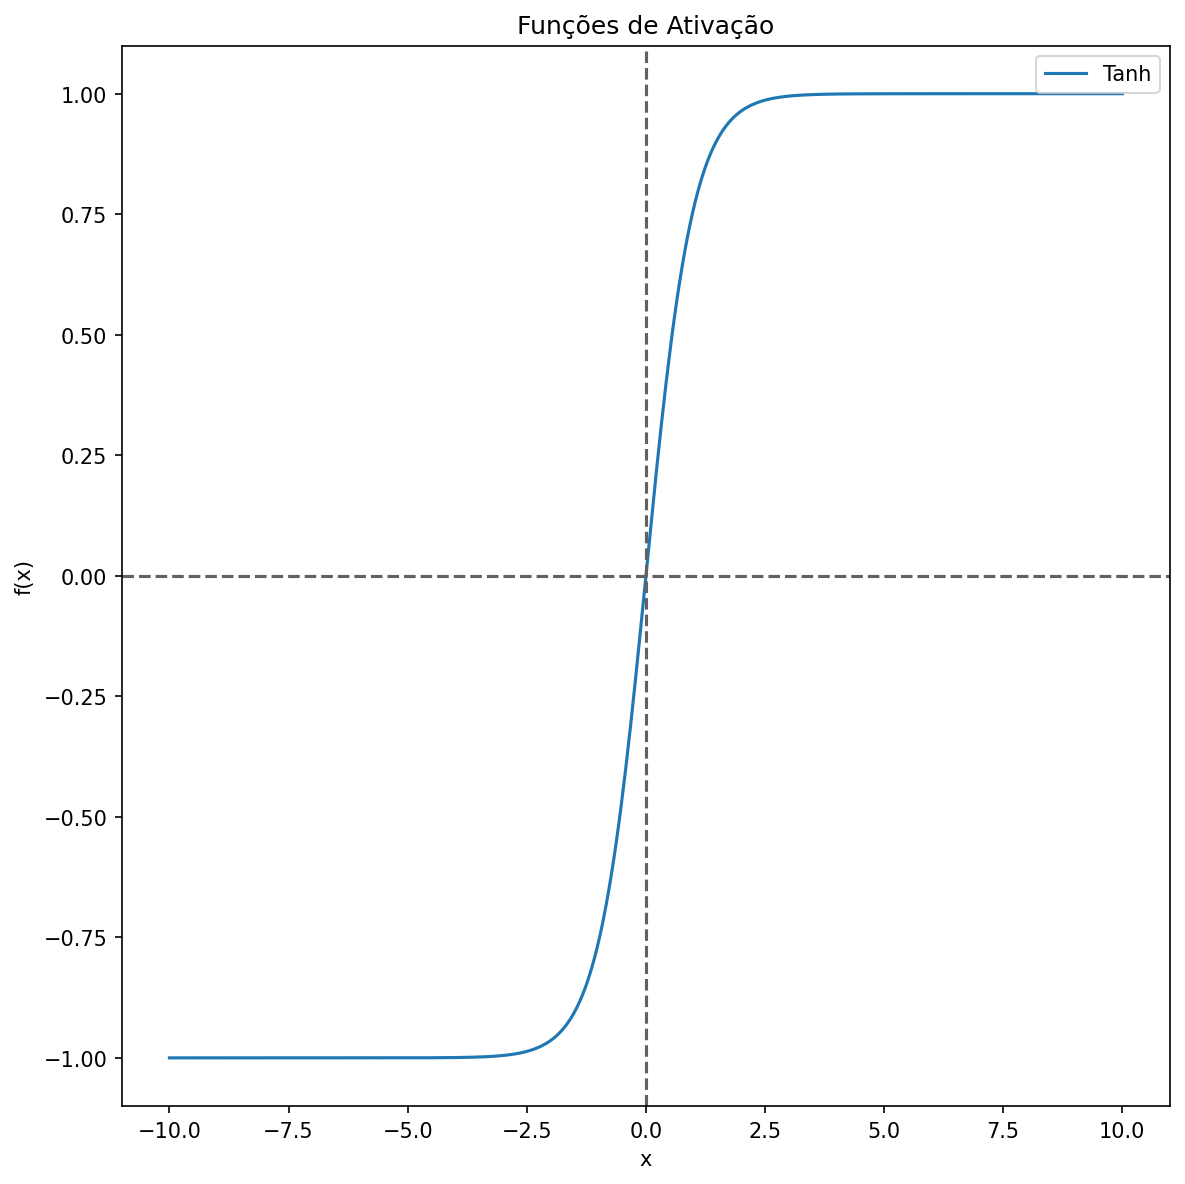

In [195]:
x = np.linspace(-10, 10, 400)
tanh = np.tanh(x)

fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
ax.plot(x, tanh, label='Tanh')

# Eixos e legenda
cor = "#616161FF"
plt.axvline(0, linestyle='--', color=cor)
plt.axhline(0, linestyle='--', color=cor)
plt.legend()
plt.title('Funções de Ativação')
plt.xlabel('x')
plt.ylabel('f(x)')


plt.tight_layout()
plt.show()

### Vamos perder... Losses

Como bons estudantes, as redes estudam para errar menos. Mas errar menos em que? Qual é a prova? A prova são as condições que sabemos serem verdades, como a equação diferencial, o contorno e as condições iniciais. No caso do código em questão essas losses (resíduos)foram implementados na `classe Ponte`. Os métodos em si constam abaixo. Estão fora de sua classe por motivo ilustrativo.

Veja que como são 3 resíduos, é necessário minimizar os 3. É possível fazer isso ao pedir que a soma deles seja minimizada. Contudo, não podemos esperar que os erros estejam em mesma escala, afinal são de frutos diferentes. Por esse motivo o que o otimizador realmentereduzirá será uma combinação linear das losses.

$$
L_{\text{total}} = \lambda_f L_f + \lambda_c L_c + \lambda_i L_i
$$

Onde $L$ é a loss e $\lambda$ o peso com os subíndices indicando física ($f$), contorno ($c$) e condição inicial ($i$).

Umas das formas de definir esses lambdas é manualmente. Outras são "automáticas". A que é usada nesse código é a técnica de GradNorm.

Um ponto importante de se considerar é que essas redes não enxergam física ou a intuem. Elas veem números. Assim, um possível problema é o mau condicionamento numérico. Ou seja, há ordens de grandeza muito diferentes e muito grandes em módulo. Isso atrapalha o treinamento, pois uma das losses acaba por dominar os gradientes. Por esse motivo é comum em problemas numéricos em geral a adimensionalização do problema. Esta foi realizada definindo uma escala de espaço, tempo e amplitudes adimensionais .

$$
\hat{x} = \frac{x}{L} \qquad \hat{t} = \frac{t}{T} \qquad \hat{u} = \frac{u}{U}
$$

Devido a essa modificação a função $u(x, t)$ vira $u(\hat{x}X, \hat{t}T)$. Devido a isso as derivadas de u são divididas pela dimensão característica elevada ao índice da derivada como segue. A demonstração fica a cargo do leitor atendo. Dica, pode ser feita pela regra da cadeia.

$$
\begin{cases}
    \frac{\rho A}{T^2} \frac{\partial ^2\hat{u}}{\partial \hat{t}^2} + \frac{c}{T}\frac{\partial \hat{u}}{\partial \hat{t}} + \frac{EI}{L^4} \frac{\partial ^2w}{\partial \hat{x}^2} = 0\\
    w = \frac{1}{L^2} \frac{\partial ^2\hat{u}}{\partial \hat{x}^2}
\end{cases}
$$

Além disso, todos os termos da primeira equação são divididos pelo fator $\frac{\rho A}{T^2}$, para torná-la adimensional. Ficamos com o seguinte sistema:

$$
\begin{cases}
    \frac{\partial ^2\hat{u}}{\partial \hat{t}^2} + \frac{cT}{\rho A}\frac{\partial \hat{u}}{\partial \hat{t}} + \frac{EIT^2}{\rho A L^4} \frac{\partial ^2w}{\partial \hat{x}^2} = 0\\
    w = \frac{1}{L^2} \frac{\partial ^2\hat{u}}{\partial \hat{x}^2}
\end{cases}
$$

Uma outra forma de tratar o erro é aplicar um hard constraint. Nesse caso o que chamamos de ansatz. Se precisamos, por exemplo, que o contorno tenah valor 0, multiplicamos a função da rede por uma função que é sempre 0 no controno. No caso de comprimento, algo como $x(L - x)$ para  um comprimento de tamanho L. Temos algo como abaixo, onde R é o resultado, D o ansatz e NN a rede neural.

$$
R(C, x_1, ..., x_n) = D(x_1, ..., x_n) \times NN(C, x_1, ..., x_n)
$$

#### Métodos

Abaixo estão, com propósito ilustrativo, os métodos que impõem o ansatz e calculam os resíduos da PINNN. Eles fazem parte da Classe Ponte, destinada à física da ponte.

In [196]:
def aplica_ansatz(self, X, nn_out):
        """Recebe a saída bruta da rede e aplica o ansatz (hard constraint)

        Args:
            X (_type_): O tensor de pontos para apicar o ansatz
            nn_out (_type_): A saída da rede

        Returns:
            _type_: O tensor com u e w
        """

        x = X[:, 0:1] # 0:1 preserva shape coluna
        ansatz = x * (1 - x)
        u = ansatz * nn_out[:, 0:1]
        w = nn_out[:, 1:2]

        return torch.cat((u, w), dim=1)

In [197]:
def residuo_fisico(self, w, u_t, u_tt, u_xx, w_xx):
        """Monta o resíduo principal da EDP. O chamado resíduo físico. Considera o sistema adimensional.

        Args:
            w (_type_): w, a segunda  dimensão do problema (derivada segunda de u)
            u_t (_type_): derivada primeira de um em t
            u_tt (_type_): derivada segunda de u em t
            u_xx (_type_): derivada segunda de u em x
            w_xx (_type_): derivada segund de w em x

        Returns:
            _type_: Os resíduos da EDP e do truque da segunda equação
        """

        zeta = self.amorteciento * self.T / self.massa_linear
        Pi = self.rigidez * self.T**2 / (self.massa_linear * self.L**4)

        R1 = u_tt + zeta * u_t + Pi * w_xx
        R2 = w - u_xx

        return R1, R2

In [198]:
def residuo_contorno(self, u_xx_0, u_xx_l):
        """Monta o resíduo das condições de contorno
        
        Args:
            u_xx_0 (_type_): A derivada segunda de u em x no ponto 0
            u_xx_l (_type_): A derivada segunda de u em x no ponto máximo (comprimento l)

        Returns:
            _type_: O resíduo relacionado às condições de contorno
        """    
         
        loss_contorno = self.perda(u_xx_0, torch.zeros_like(u_xx_0)) + self.perda(u_xx_l, torch.zeros_like(u_xx_l))
        ### u_xx_0 e u_xx_l deveriam estar divididos por L0

        return loss_contorno

In [199]:
def residuo_inicio(self, X, u, u_t):
        """Monta o resíduo da condição inicial

        Args:
            X (_type_): O tensor de pontos incerido na rede
            u (_type_): o valor de u
            u_t (_type_): a primeira derivada de u em t

        Returns:
            _type_: O resíduo relacionado às condições iniciais
        """
         
        ux0 = torch.sin(torch.pi * X) # É um perfil
        loss_inicio = self.perda(u, ux0) + self.perda(u_t, torch.zeros_like(ux0))
        ### u e u_t deveriam estar divididos por L0???

        return loss_inicio

## Lógica geral

Aqui deve ser reforçado que o código utilizado para otimizar or parâmetros das redes, otimizar/treinar a rede, etc, foi escrito na "modalidade" script. Se encontram na pasta "src" e dedicam-se a criar a estrutura da rede, seus datasets e possibilitar os cálculos de derivadas e otimizar hiperparâmetros. São cerca de 500 linhas de código total. Isso prejudicaria a visualização do notebook, por isso optar por não colocá-los aqui.

A lógica de funcionamento é simples. A classe DataModule é responsável por gerar conjuntos de dados sem dimensão específica (problema adimensional) pertencentes ao conjunto [0, 1]. Os pontos gerados podem ser do interior (soberania da equação diferencial), contorno (soberania do contorno) e início (soberania das condições iniciais). Estes pontos passam pela rede de forma sequencial. Em uma época passam pontos de todos esses conjuntos (isso foi uma opção). A rede gera um valor em sua saída, nesse caso, 2 valores, $u$ e $w$.

Comparamos a saída com o que esperávamos obter em cada soberania. Para isso, funções de diferenciação automática são empregadas. Esse processo resulta em losses que devem ser reduzidas igualmente. Para isso há alguns modos. O escolhido foi o GradNorm. Como a função de perda final combina de forma linear as losses, podemos ajudar os pesos da combinação com base nos gradientes da rede (mais especificamente da última camada). Se a variação for grande, podemos pesar menos e favorecer uma loss que estava menos visível. Assim garantimos que a rede aprenderá todas as restrições que colocamos. Garantir é uma palavra forte, pois o problema determina em muito o funcionamento da PINN.

## O que obtive dos testes

### Funções de perda

O processo de criação desta rede foi longo, tendo durado várias semanas, que estão registradas no GitHub (https://github.com/RobertJbkc/PINN-Ponte-de-vidro). Durante esse tempo o conjunto de hiperparâmetros foi otimizado algumas vezes em lotes de 100 trial. Isso pois era necessário verificar a funcionalidade do código e que o valor da loss de validação estava baixo e caia pelas épocas. Nesse processo, redes sem adimensionalização foram otimizadas, assim como semi-adimensionalizadas e totalmente adimensionalizadas. Abaixo há 4 gráficos. Na linha superior a otimização foi feita visando um intervalo de tempo de 10 s. Nas linhas de baixo foi feita em um intervalo de 0.5 s, visando o melhor condicionamento numérico.

Abaixo ploto a curva de aprendizado das melhores versões dessas redes para mostrar como a adimensionalização é interessante.

In [200]:
def encontra_trial_csv(caminho_experimento):

    caminho_experimento = Path(caminho_experimento)
    caminho_db = caminho_experimento / 'db'

    # Arquivo .db
    arquivo_db = next(caminho_db.glob('*.db'))

    storage = f'sqlite:///{arquivo_db}'

    # Nome do estudo
    nome_estudo = optuna.study.get_all_study_summaries(storage)[0].study_name

    # Carregar estudo
    study = optuna.load_study(
        study_name=nome_estudo,
        storage=storage
    )

    # Melhor trial
    best_trial = study.best_trial.number

    # Pasta do trial
    caminho_trial = (caminho_experimento/ 'logs'/ 'PINN'/ f'trial_{best_trial}')

    # CSV
    arquivo_csv = next(caminho_trial.glob('*.csv'))

    return arquivo_csv, study

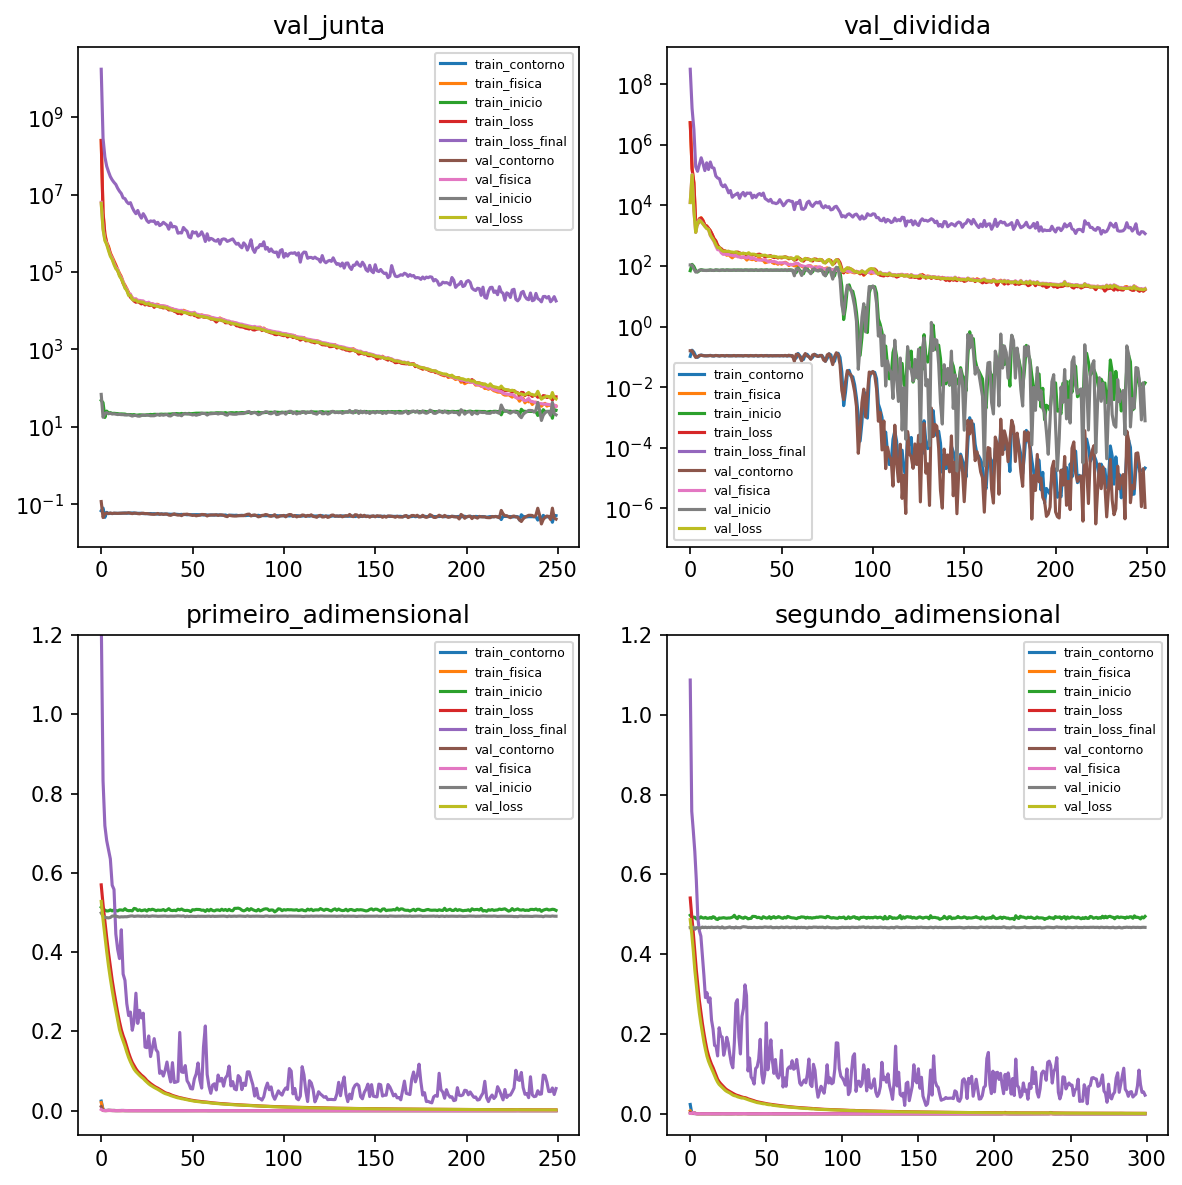

In [201]:
lista_experimentos = ['val_junta', 'val_dividida',  'primeiro_adimensional',  'segundo_adimensional']

fig, ax = plt.subplots(2, 2, figsize=(8, 8), dpi=150)
eixos = [ax[0][0], ax[0][1], ax[1][0], ax[1][1]]


for quadro, j in enumerate(lista_experimentos):
    caminho_csv, _ = encontra_trial_csv(f'./dados_otimizacao/{j}')

    df = pd.read_csv(caminho_csv, header=0)
    df_ = df[['epoch'] + [i for i in df.columns if i.startswith('train_')]].dropna()
    df = df[['epoch'] + [i for i in df.columns if i.startswith('val_')]].dropna()

    # ========== Plotagem ==========
    treino = list(df_.columns)
    treino.remove('epoch')

    val = list(df.columns)
    val.remove('epoch')

    for i in treino:
        eixos[quadro].plot(df_['epoch'], df_[i], label=f'{i}')

    for i in val:
        eixos[quadro].plot(df['epoch'], df[i], label=f'{i}')

    eixos[quadro].legend(fontsize=6)
    eixos[quadro].set_title(j)

eixos[0].set_yscale('log')
eixos[1].set_yscale('log')

eixos[2].set_ylim(None, 1.2)
eixos[3].set_ylim(None, 1.2)


plt.tight_layout()
plt.show()

A primeira impressão é de que algo de errado não está certo. E isso provavelmente é verdade. Digo isso pois as losses não estão caindo igualmente mesmo no último gráfico, que é o estado quase atual da rede. Contudo, podemos perceber pontos interessantes. Primeiro, a escala de erro das redes sem adimencionalização é maior. Isso pode ser observado pela estabilização mais rápida das losses principais das redes adimensionais. O primeiro (val_junta) é resultado de um código que escolhia pontos interior (1000 pontos), contorno (500 pontos) e início (500 pontos), mas validava com 3000 pontos aleatórios no domínio inteiro. Assim, o peso da validação era maior e a probabilidade de pontos no contorno ou início era quase 0. Isso explica o grande erro associado. Ao seu lado está o resultado com a validação por região com 500, 250 e 250 pontos respectivamente. Apenas isso foi suficiente para melhora ro resultado, ou seja, as losses se aproximaram mais do 0.

Vale mais a pena verificar os dados referentes as redes adimencionalizadas. Os gráficos inferiores representam dois testes. O primeiro mostra uma rede com adimensionalização parcial, pois apenas as dimensões de entrada estavam adimensioanlizadas. A segunda mostra o resultado de uma rede com o processo completo. Mais que isso, elas foram todas treinadas com o fator de tempo característico ($T = 0.5$), que é o intervalo de tempo que oferece a maior estabilidade numérica ao compensar os termos de amortecimento e rigidez. O que não impede que a rede seja estrapolada. O principal que chama a atenção são as losses de início que são constantes. Isso indica claramente que a rede não aprende as condições iniciais do problema. O que pode ser fruto de um erro no GradNorm ou mesmo de um erro na função de perda. Como implicação, não é esperado que estas redes tenham a mesma amplitude de oscilação que a solução analítica  do problema.

## Modelo final

### Criando o modelo final

Após a rede passar pela otimização de parâmetros podemos, finalmente, montar a "rede final". Esta entrará em uma esperada disputa com a solução analítica para garantir que foi uma "boa ideia". Abaixo os parâmetros das classes envolvidas na criação da rede são definidos e os melhores parâmetros são inseridos no grande dicionário. Algumas chaves do dicionário refletem a otimização e não serão utilizadas. Vale dizer que a rede que será realmente montada é fruto de uma 5 otimização, listada como "Final" na pasta de otimizações. Esta também é adimensional, mas foi otimizada para um período de tempo de 20 s. Afinal, se a rede é treinada no ótimo de 0.5 s, ela tem de extrapolar os pontos fora do domínio. Devido a isso optei por treiná-la para um domínio maior, visando ter uma função com dimensões mais realistas de tempo (macroscópicas).

In [202]:
import torch.nn as nn

problema = Ponte(comprimento=20, T=20, massa_linear=800, amorteciento=2000, rigidez=5e8)
configs = {
        'experimento': {
            'nome': '1_alfa_300_adimencional',
            'n_trials': 100,
            'max_epochs': 300 
        },
        'otimizador': {},
        'DataModule': {
            'np_interior': 1000,
            'np_contorno': 500,
            'np_inicio': 500,
            'np_interior_val': 500,
            'np_contorno_val': 250,
            'np_inicio_val': 250,
            'dimensoes': 2,
        },
        'Module': {
            'dimensoes': 2,
            'num_saidas': 2,
            'funcao_ativacao': nn.Tanh,
            'problema': problema
        }
    }

_, best_params = encontra_trial_csv('./dados_otimizacao/Final')
best_params = best_params.best_params
display(configs)

print('\nDicionário de parâmetros atualizados')
configs['DataModule']['batch_size'] = best_params.pop('batch_size')
configs['Module']['camadas_o'] = [best_params.pop(i) for i in best_params.copy() if i.startswith('Neurônios_')]
best_params.pop('num_layers')
configs['Module'].update(best_params)
display(configs)

{'experimento': {'nome': '1_alfa_300_adimencional',
  'n_trials': 100,
  'max_epochs': 300},
 'otimizador': {},
 'DataModule': {'np_interior': 1000,
  'np_contorno': 500,
  'np_inicio': 500,
  'np_interior_val': 500,
  'np_contorno_val': 250,
  'np_inicio_val': 250,
  'dimensoes': 2},
 'Module': {'dimensoes': 2,
  'num_saidas': 2,
  'funcao_ativacao': torch.nn.modules.activation.Tanh,
  'problema': <pinn_alfa.Ponte at 0x1a9067eeb10>}}


Dicionário de parâmetros atualizados


{'experimento': {'nome': '1_alfa_300_adimencional',
  'n_trials': 100,
  'max_epochs': 300},
 'otimizador': {},
 'DataModule': {'np_interior': 1000,
  'np_contorno': 500,
  'np_inicio': 500,
  'np_interior_val': 500,
  'np_contorno_val': 250,
  'np_inicio_val': 250,
  'dimensoes': 2,
  'batch_size': 32},
 'Module': {'dimensoes': 2,
  'num_saidas': 2,
  'funcao_ativacao': torch.nn.modules.activation.Tanh,
  'problema': <pinn_alfa.Ponte at 0x1a9067eeb10>,
  'camadas_o': [2, 4, 9, 4, 8],
  'lr': 0.005538234199451508}}

Instanciamos as duas classes core da rede extraindo o dicionário expecífico para cada uma.

In [203]:
dm = DataModule(**configs['DataModule'])
modelo = Module(**configs['Module'])

caminho_base = Path('./')

Abaixo configuro um logger CSV que tem como função armazenar as losses por época para posterior análise. O treinador é definido e o número de épocas é de $300$, valor mais do que suficiente para garantir a convergência nos casos observados.

In [204]:
logger_CSV = CSVLogger(
    save_dir=caminho_base / 'logs',
    name='PINN',
    version=f'Final'
)

# ===== Trainer =====
treinador = L.Trainer(
    max_epochs=configs['experimento']['max_epochs'],
    logger=logger_CSV,
    devices=1,
    accelerator='cpu',
    enable_progress_bar=True,
    enable_model_summary=False, # Evita prints extras
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Um adendo é que, para o código não fitar uma rede nova a cada "Run All", há o condicional abaixo que impede o novo fit. Basta definí-lo como `True` e o código otimizará uma nova rede e salvará sobrescrevendo  os parâmetros anteriores. a 

In [205]:
rodar = False

if rodar:
    treinador.fit(modelo, dm)
    nome_arquivo = './logs/Rede_neural_final.pth'
    torch.save(modelo.state_dict(), nome_arquivo)

In [206]:
nome_arquivo = './logs/Rede_neural_final.pth'
state_dict = torch.load(nome_arquivo, weights_only=True)
modelo.load_state_dict(state_dict)

<All keys matched successfully>

A última tarefa dessa seção é confirmar que a otimização ocorreu corretamente plotando a curva de aprendizado. Abaixo discuto o que podemos abstrair da curva.

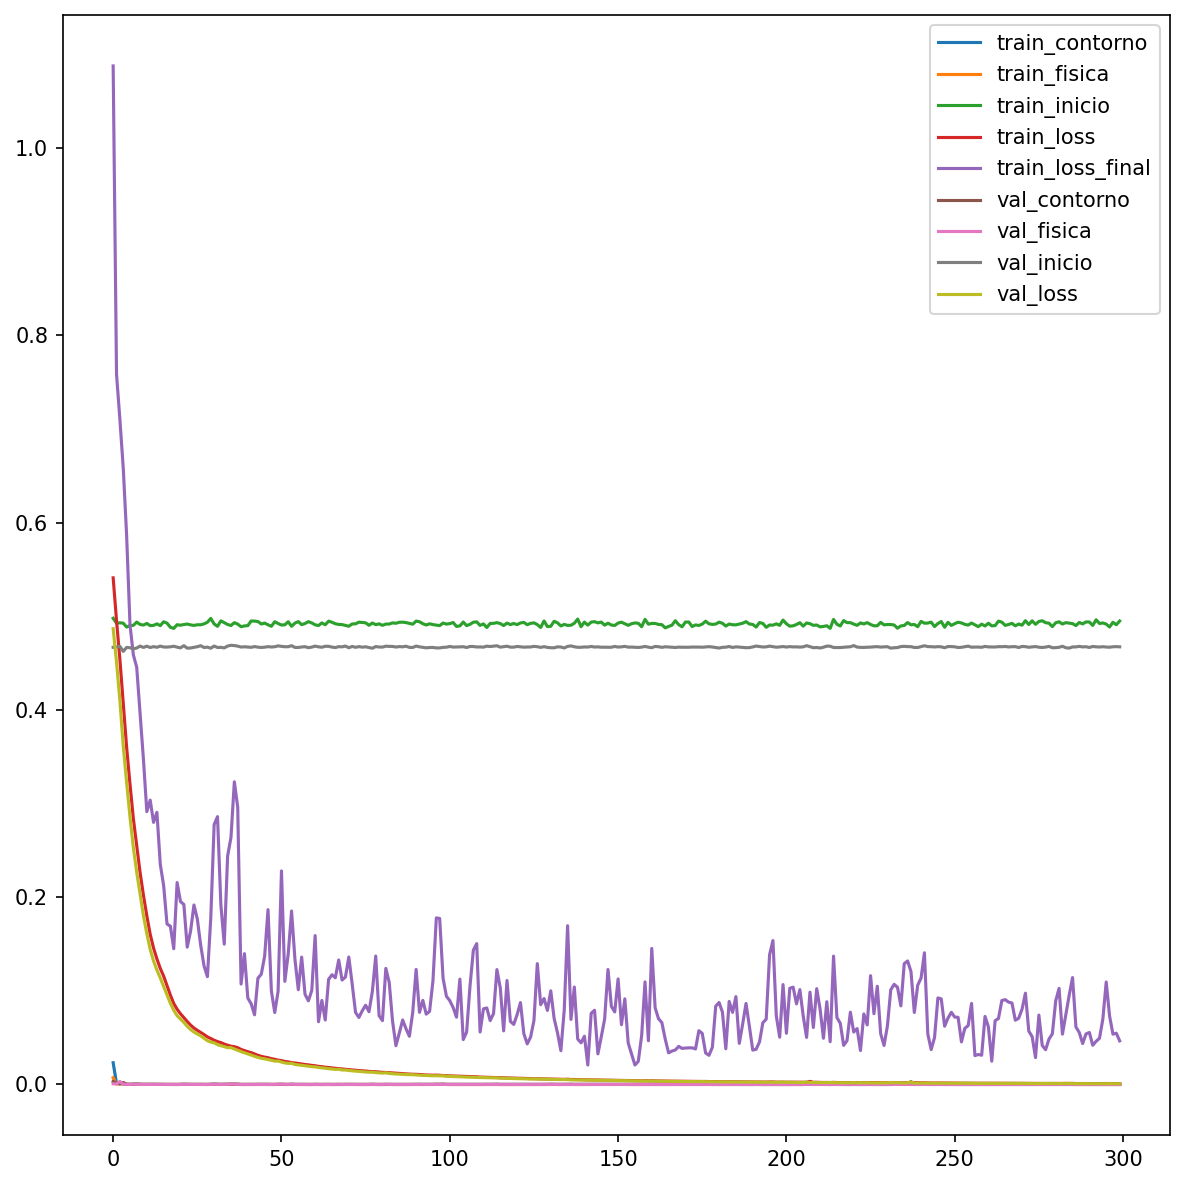

In [207]:
caminho_curva_l = './logs/PINN/Final/metrcs.csv'
df = pd.read_csv(caminho_csv, header=0)
df_ = df[['epoch'] + [i for i in df.columns if i.startswith('train_')]].dropna()
df = df[['epoch'] + [i for i in df.columns if i.startswith('val_')]].dropna()

# ========== Plotagem ==========
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
treino = list(df_.columns)
treino.remove('epoch')

val = list(df.columns)
val.remove('epoch')

for i in treino:
    ax.plot(df_['epoch'], df_[i], label=f'{i}')

for i in val:
    ax.plot(df['epoch'], df[i], label=f'{i}')

ax.legend()


plt.tight_layout()
plt.show()

Assim como visto para as outras curvas de aprendizado das redes adimensional, as losses estão caindo, com exceção das de início. Em decorrência do ansatz as perdas de contorno tem valor reduzido desde o começo da otimização. E, mesmo com a constante no resíduo de início a loss total que sai do GradNorm em função dos pesos e ajustes realizados ainda cai.

### Avaliando o modelo

#### Solução analítica

Para os fins deste notebook o principal é comparar a rede criada com a solução analítica do problema, pois ela é, acima de tudo, a lei. Devo dizer que algumas escolhas foram escolhidas para garantir que a solução analítica existisse, condições sestas como a forma da condição inicial, que é um perfil do tipo

$$
u(x, 0) = A\sin(\frac{\pi x}{L})
$$

Esta faz com que o primeiro modo vibracional da ponte seja excitado e possibilita uma solução simples.

A solução pode ser obtida por separação de variáveis. Partindo da equação da viga

$$
    \mu \frac{\partial^2 u}{\partial t^2} + c \frac{\partial u}{\partial t} + EI \frac{\partial^4 u}{\partial x^4} = 0
$$

supomos que $u(x,t)=X(x)T(t)$. Isto nos leva a uma equação separável. Escolhemos, então, o fator de separação $\lambda$.

$$
    \mu \frac{T''}{T} + c \frac{T'}{T} + EI \frac{X''''}{X} = 0  \longrightarrow  EI \frac{X''''}{X}=\lambda  \qquad  \mu \frac{T''}{T} + c \frac{T'}{T} = -\lambda
$$

Resolvendo separadamente e impondo o primeiro modo vibracional obtemos a solução abaixo, que é implementada como método de classe na classe Ponte. O método está abaixo com propósito ilustrativo.

$$
    u(x,t)= A \sin\left(\frac{\pi x}{L}\right) e^{-\alpha t} \cos(\omega_d t)
$$

In [208]:
def solucao_analitica(self, x0, xf, t0, tf, n_pontos):

    x = np.linspace(x0, xf, n_pontos)
    t = np.linspace(t0, tf, n_pontos)

    X, T = np.meshgrid(x, t)

    # ===== parâmetros físicos =====
    mu = self.massa_linear
    c  = self.amorteciento
    EI = self.rigidez
    L  = self.L

    # ===== amplitude inicial =====
    A = 0.01

    # ===== frequências =====
    alpha = c / (2 * mu)

    omega_n = np.sqrt(
        (EI / mu) * (np.pi / L)**4
    )

    omega_d = np.sqrt(
        omega_n**2 - alpha**2
    )

    # ===== solução =====
    U = (
        A
        * np.sin(np.pi * X / L)
        * np.exp(-alpha * T)
        * np.cos(omega_d * T)
    )

    return X, T, U

#### Apicando a solução e a rede

Como foi dito, o grande objetivo é comparar a solução analítica com a solução da rede. Para não fazer bagunça, a seção atual tem por fim apenas passar uma malha de pontos $x$ e $y$ pela rede e pela solução analítica. Novamente, por eficiência e organização os métodos estão implementados na classe Ponte. Ainda assim, os métodos estão disponíveis no notebook com propósito didático. Abaixo o da PINN e acima o da solução analítica.

In [209]:
def avaliar_pinn(self, x0, xf, t0, tf, n_pontos_x, n_pontos_t, modelo):
    x_fisico = np.linspace(x0, xf, n_pontos_x)
    t_fisico = np.linspace(t0, tf, n_pontos_t)
    x = x_fisico / self.L
    t = t_fisico / self.T
    X, T = np.meshgrid(x, t)

    XT = np.column_stack([ X.ravel(), T.ravel()])

    XT_tensor = torch.tensor(XT, dtype=torch.float32, device=modelo.device)

    modelo.eval()

    with torch.no_grad():
        U = modelo(XT_tensor)[:, 0].cpu().numpy()

    U = U.reshape(X.shape)
    U_fisico = U ### Definir o atributo amplitude

    return x_fisico, t_fisico, U_fisico

A partir de agora o objetivo é colocar as malhas na rede e obter as variáveis índice *rede* e *analitica*. Vou instanciar novamente a classe Ponte para deixá-la próxima ao nosso uso. O intervalo de tempo pedido era de 10 s, dentro do intervalo de tempo de treino.

In [210]:
problema = Ponte(comprimento=20, T=0.5, massa_linear=800, amorteciento=2000, rigidez=5e8)

x_rede, t_rede, u_rede = problema.avaliar_pinn(x0=0, xf=20, t0=0, tf=10, n_pontos_x=100, n_pontos_t=100, modelo=modelo)
x_analitica, t_analitica, u_analitica = problema.solucao_analitica(x0=0, xf=20, t0=0, tf=10, n_pontos_x=100, n_pontos_t=100)

##### Comparando tempos específicos

Imaginando uma ponte dado que seu meio foi levantado, a tendência é que esta oscile e que as amplitudes caiam com o tempo. O teste abaixo faz justamente isso. 5 tempos são selecionados e plotados juntos com as soluções analíticas correspondentes. O esperado é que a rede e a solução estejam sobrepostas. Contudo, dada a curva de aprendizado, isso é improvável.

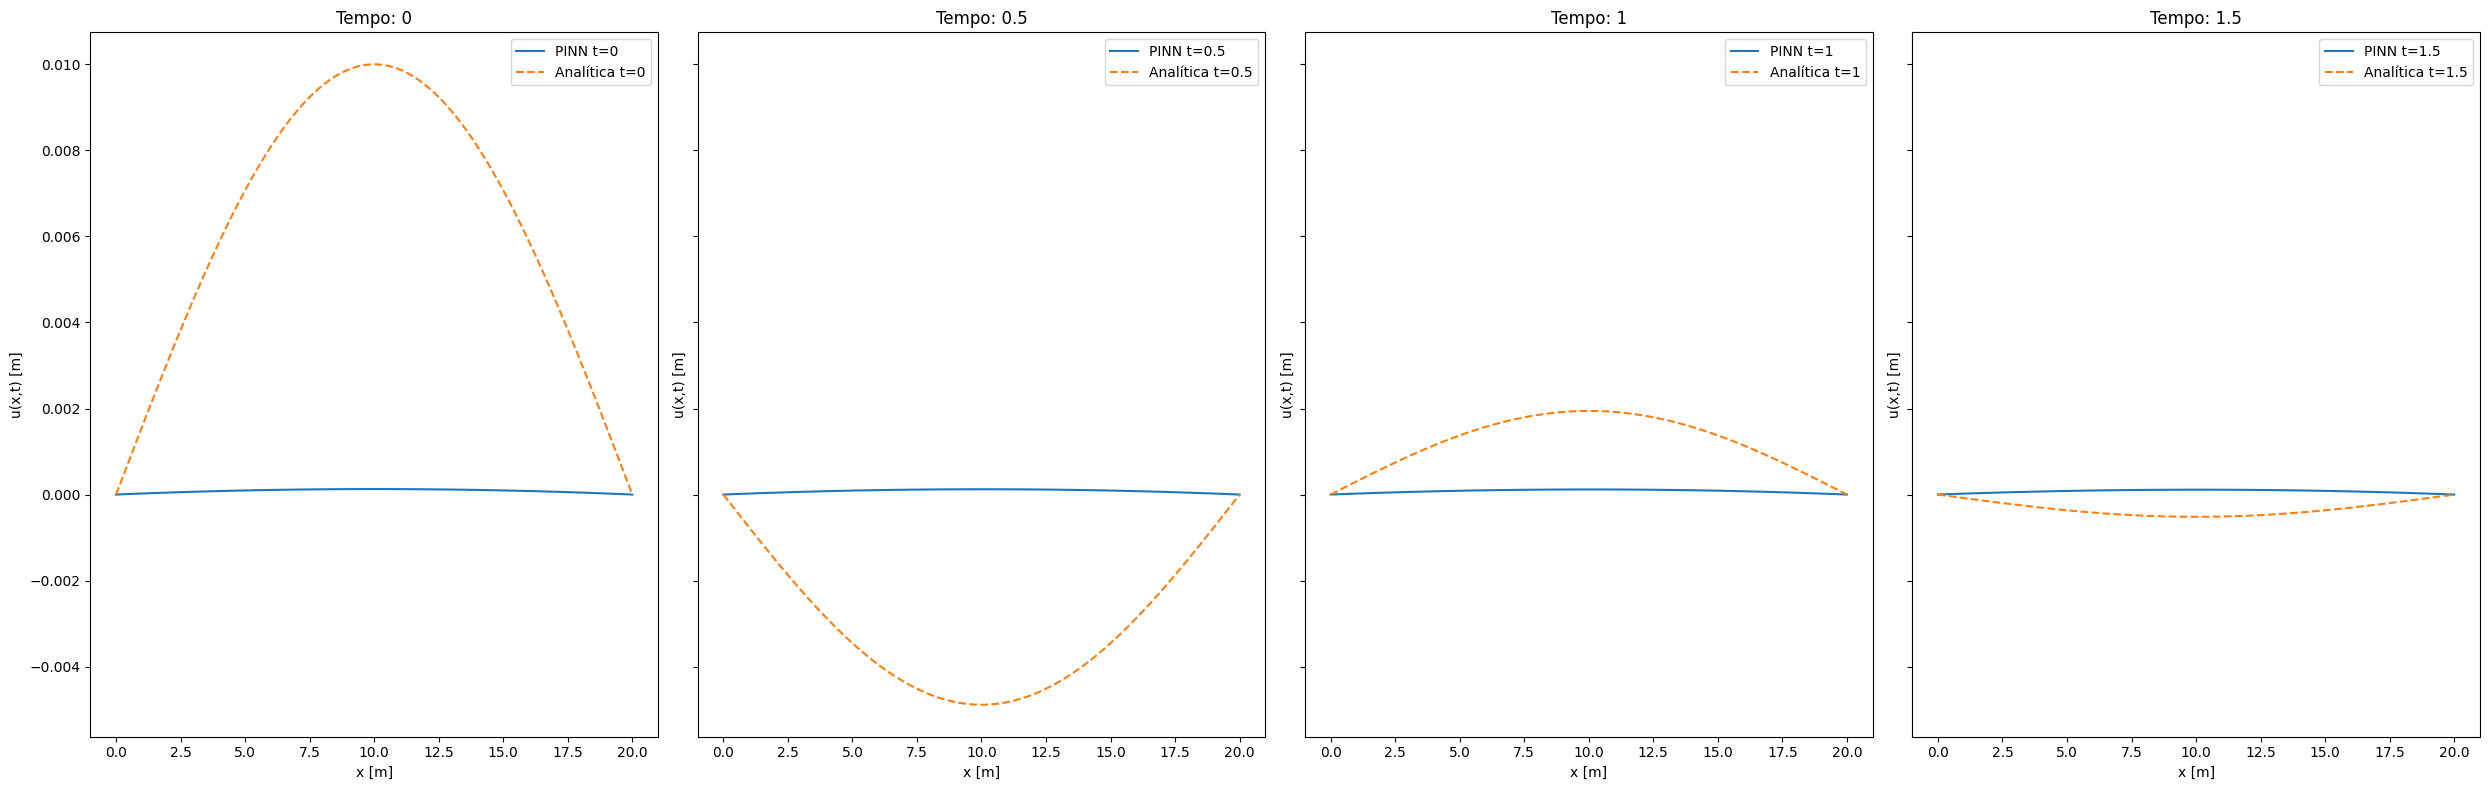

In [211]:
# ===== tempos escolhidos =====
tempos = [0, 0.5, 1, 1.5]

fig, ax = plt.subplots(1, 4, figsize=(25, 8), sharey=True)

for i, tempo in enumerate(tempos):

    # índice temporal mais próximo
    idx_rede = np.argmin(np.abs(t_rede - tempo))
    idx_analitica = np.argmin(np.abs(t_analitica - tempo))

    # ===== PINN =====
    ax[i].plot(
        x_rede,
        u_rede[idx_rede, :],
        label=f'PINN t={tempo}'
    )

    # ===== analítica =====
    ax[i].plot(
        x_analitica,
        u_analitica[idx_analitica, :],
        '--',
        label=f'Analítica t={tempo}'
    )

    ax[i].set_xlabel('x [m]')
    ax[i].set_ylabel('u(x,t) [m]')
    ax[i].legend()
    ax[i].set_title(f'Tempo: {tempo}')

# ax.grid(True)

plt.tight_layout()
plt.show()

Foram feitos 4 plots com tempos escolhidos arbitrariamente seguindo a regra de começar no 0 e acrescentar 0.5. Por mais que o intervalo de tempo tenha sido escolhido para 10 s, não é necessário ir até o final para verificar o arro da rede. Há uma grande imprecisão na amplitude da oscilação, que pode ser percebida no tempo 0. Ambas deveriam estar sobrepostas com pico em 0.01. Mais que isso, ao observar a dinâmica temporal, evidente devido ao passos de tempo escolhidos entre os gráficos, percebe-se que há uma defasagem entre as funções. Já no segundo momento a rede está em um ponto elevado quando deveria estar me um ponto reduzido. Isso compromete em muito a simulação, pois mostra que as funções representam pontes de naturezas diferentes. Ou seja, a PINN não foi capaz de aprender o problema físico.

##### Erro relativo à analítica

In [212]:
erro = u_rede - u_analitica
mse = np.mean(erro**2)
rmse = np.sqrt(mse)

erro_relativo = np.mean(
    np.abs(erro) / (np.abs(u_analitica) + 1e-12)
)

print(f'MSE  = {mse:.6e} m^2')
print(f'RMSE = {rmse:.6e} m')
print(f'Erro relativo médio = {erro_relativo:.6%}')

MSE  = 1.246820e-06 m^2
RMSE = 1.116611e-03 m
Erro relativo médio = 4660.740151%


O erro pode não parecer grande coisa em valor (RMSE). Contudo, fica claro, pelo erro relativo que há uma divergência entre os métodos de resolver o problema. Isso já era esperado, afinal vimos que há uma defasagem entre as funções. Mais que isso, a condição inicial definiu uma amplitude máxima de 1 mm. O erro RMSE acaba por ser maior que isso. O que indica a falha no aprendizado do problema.

## Conclusões

Em suma, foi possível trinar uma rede neural do tipo PINN que aprendeu que há um comportamento oscilatório nas vibrações de uma ponte. Foi possível notar o esforço da rede ao analizar sua curva de aprendizado, que claramente possuía tendência a 0. Contudo, também foi possível notar que a loss correspondente às condições iniciais não foi aprendida. Portanto, o que foi obtido ao final é uma rede que domina oscilações mas não compreende de onde elas veem. Os gráficos comparativos com uma solução analítica mostraram a defasagem da rede com o "real" e chamam atenção para a implementação das losses. Mais que isso, a análise do erro relativo e RMSE apontaram para o mesmo problema, refletido do erro de condição inicial. Evidente pelo erro maior que a amplitude máxima.

Ainda assim, foi possível estruturar um bom código em questão de modularização e orientação a objeto. Ou seja, é relativamente fácil, após identificar um problema, corrigi-lo.

# Referêncais

- [1] Physics-informed neural networks: A deep learning
framework for solving forward and inverse problemas involving
nonlinear partial differential equations DOI: 10.1016/j.jcp.2018.10.045
- [2] Texto informativo sobre funções de ativação. Disponível em: https://medium.com/@sushmita2310/12-types-of-activation-functions-in-neural-networks-a-comprehensive-guide-a441ecefb439
- [3] Physics-informed machine learning DOI: DOI: 10.1038/s42254-021-00314-5